In [9]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import plotting

df = pd.read_csv("../data/processed/cleaned_combined.csv", index_col=0, parse_dates=True)

# Pivot into wide format: one column per ticker, needed by PyPortfolioOpt
prices = df.pivot_table(index=df.index, columns="Ticker", values="Close")
prices = prices[["TSLA", "BND", "SPY"]]  # consistent column order
prices.tail()

Ticker,TSLA,BND,SPY
Date,,,
2026-06-23,381.609985,73.220001,733.580017
2026-06-24,375.529999,73.550003,733.239990
2026-06-25,375.119995,73.599998,734.299988
2026-06-26,379.709991,73.669998,728.989990
2026-06-29,411.839996,73.709999,741.000000


In [10]:
# TSLA expected return: from Task 3's LSTM forecast (computed in notebook 2.0)
# Forecast: $411.84 -> $316.06 median over 252 trading days (~12 months)
tsla_start_price = 411.84
tsla_forecast_end_price = 316.06
forecast_days = 252
forecast_years = forecast_days / 252

tsla_forecasted_annual_return = (tsla_forecast_end_price / tsla_start_price) ** (1 / forecast_years) - 1
print(f"TSLA forecasted annualized return (from LSTM): {tsla_forecasted_annual_return:.4f} ({tsla_forecasted_annual_return*100:.2f}%)")

# BND and SPY: historical average daily return, annualized
hist_returns = prices.pct_change().dropna()
bnd_annual_return = hist_returns["BND"].mean() * 252
spy_annual_return = hist_returns["SPY"].mean() * 252

print(f"BND historical annualized return: {bnd_annual_return:.4f} ({bnd_annual_return*100:.2f}%)")
print(f"SPY historical annualized return: {spy_annual_return:.4f} ({spy_annual_return*100:.2f}%)")

mu = pd.Series({
    "TSLA": tsla_forecasted_annual_return,
    "BND": bnd_annual_return,
    "SPY": spy_annual_return,
})
mu

TSLA forecasted annualized return (from LSTM): -0.2326 (-23.26%)
BND historical annualized return: -0.0082 (-0.82%)
SPY historical annualized return: 0.1231 (12.31%)


TSLA   -0.232566
BND    -0.008237
SPY     0.123098
dtype: float64

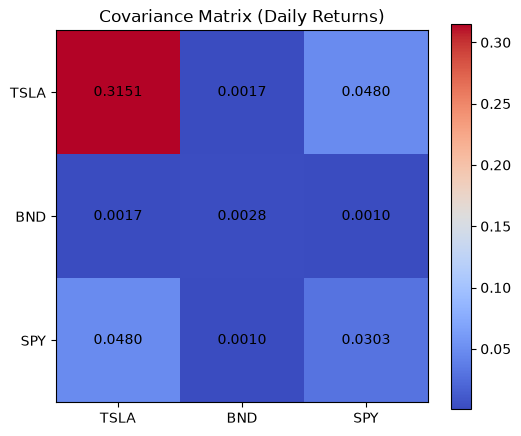

Ticker,TSLA,BND,SPY
Ticker,,,
TSLA,0.315057,0.001727,0.047991
BND,0.001727,0.002778,0.001007
SPY,0.047991,0.001007,0.030261


In [11]:
S = risk_models.sample_cov(prices)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(S, cmap="coolwarm")
ax.set_xticks(range(len(S.columns)))
ax.set_yticks(range(len(S.columns)))
ax.set_xticklabels(S.columns)
ax.set_yticklabels(S.columns)
for i in range(len(S.columns)):
    for j in range(len(S.columns)):
        ax.text(j, i, f"{S.iloc[i, j]:.4f}", ha="center", va="center")
plt.colorbar(im)
ax.set_title("Covariance Matrix (Daily Returns)")
plt.show()

S

In [12]:
from pypfopt import EfficientFrontier
import copy

mu_arr = mu  # already a pd.Series indexed TSLA, BND, SPY
S_arr = S    # already a covariance DataFrame

# Max Sharpe Ratio portfolio (Tangency Portfolio)
ef_max_sharpe = EfficientFrontier(mu_arr, S_arr)
weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=0.0)
cleaned_max_sharpe = ef_max_sharpe.clean_weights()
ret_max_sharpe, vol_max_sharpe, sharpe_max_sharpe = ef_max_sharpe.portfolio_performance(risk_free_rate=0.0)

print("=== Max Sharpe Ratio Portfolio ===")
print(cleaned_max_sharpe)
print(f"Expected annual return: {ret_max_sharpe:.4f} ({ret_max_sharpe*100:.2f}%)")
print(f"Annual volatility: {vol_max_sharpe:.4f} ({vol_max_sharpe*100:.2f}%)")
print(f"Sharpe Ratio: {sharpe_max_sharpe:.4f}\n")

# Min Volatility portfolio (separate EfficientFrontier instance — PyPortfolioOpt
# optimizers are stateful and can only be solved once per instance)
ef_min_vol = EfficientFrontier(mu_arr, S_arr)
weights_min_vol = ef_min_vol.min_volatility()
cleaned_min_vol = ef_min_vol.clean_weights()
ret_min_vol, vol_min_vol, sharpe_min_vol = ef_min_vol.portfolio_performance(risk_free_rate=0.0)

print("=== Minimum Volatility Portfolio ===")
print(cleaned_min_vol)
print(f"Expected annual return: {ret_min_vol:.4f} ({ret_min_vol*100:.2f}%)")
print(f"Annual volatility: {vol_min_vol:.4f} ({vol_min_vol*100:.2f}%)")
print(f"Sharpe Ratio: {sharpe_min_vol:.4f}")

=== Max Sharpe Ratio Portfolio ===
OrderedDict({'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0})
Expected annual return: 0.1231 (12.31%)
Annual volatility: 0.1740 (17.40%)
Sharpe Ratio: 0.7076

=== Minimum Volatility Portfolio ===
OrderedDict({'TSLA': 0.0, 'BND': 0.94291, 'SPY': 0.05709})
Expected annual return: -0.0007 (-0.07%)
Annual volatility: 0.0517 (5.17%)
Sharpe Ratio: -0.0143


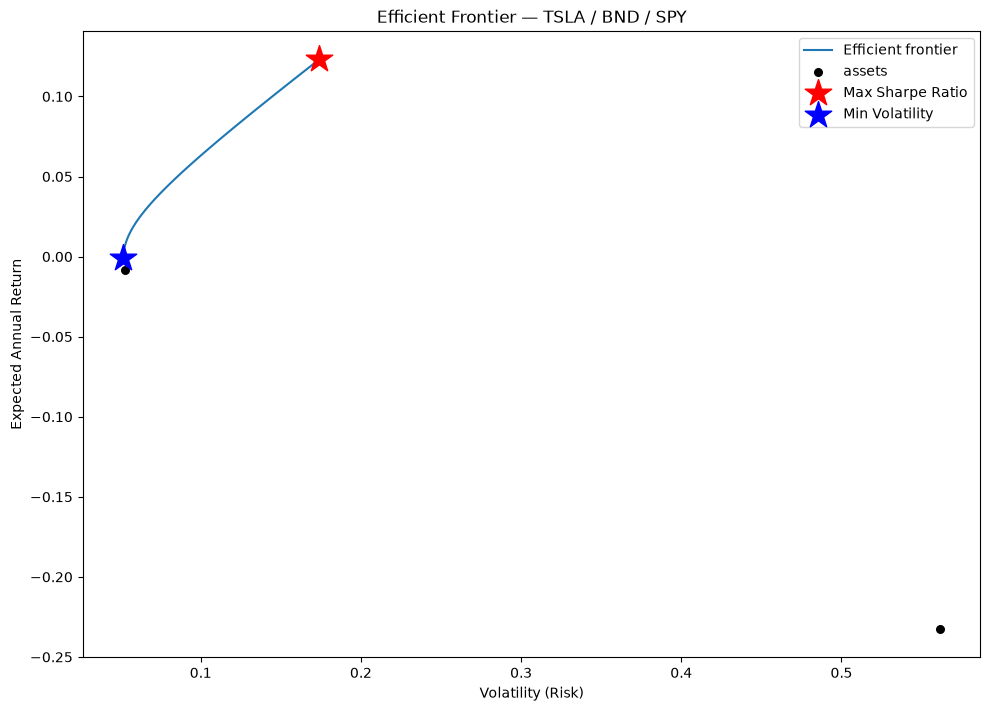

In [13]:
from pypfopt import plotting

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the frontier curve (uses a fresh instance since plotting also consumes the object)
ef_plot = EfficientFrontier(mu_arr, S_arr)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# Mark Max Sharpe and Min Vol portfolios
ax.scatter(vol_max_sharpe, ret_max_sharpe, marker="*", s=400, c="red", label="Max Sharpe Ratio", zorder=5)
ax.scatter(vol_min_vol, ret_min_vol, marker="*", s=400, c="blue", label="Min Volatility", zorder=5)

ax.set_title("Efficient Frontier — TSLA / BND / SPY")
ax.set_xlabel("Volatility (Risk)")
ax.set_ylabel("Expected Annual Return")
ax.legend()
plt.show()

In [14]:
recommendation = cleaned_max_sharpe  # or cleaned_min_vol, decide after seeing results

print("=== RECOMMENDED PORTFOLIO ===")
for asset, weight in recommendation.items():
    print(f"{asset}: {weight*100:.2f}%")
print(f"\nExpected Annual Return: {ret_max_sharpe*100:.2f}%")
print(f"Expected Annual Volatility: {vol_max_sharpe*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_max_sharpe:.4f}")

=== RECOMMENDED PORTFOLIO ===
TSLA: 0.00%
BND: 0.00%
SPY: 100.00%

Expected Annual Return: 12.31%
Expected Annual Volatility: 17.40%
Sharpe Ratio: 0.7076


## Task 4: Portfolio Recommendation

**Recommended Portfolio: 100% SPY** (Max Sharpe Ratio / Tangency Portfolio)

| Metric | Value |
|---|---|
| TSLA weight | 0.00% |
| BND weight | 0.00% |
| SPY weight | 100.00% |
| Expected Annual Return | 12.31% |
| Expected Annual Volatility | 17.40% |
| Sharpe Ratio | 0.71 |

**Justification:** Given the LSTM forecast's negative expected return for TSLA (-23.26%) 
and BND's negative historical average return over this window (-0.82%), SPY is the only 
one of the three assets with a positive expected return, so no combination of the three 
assets improves on holding SPY alone from a mean-variance perspective. The Minimum 
Volatility alternative (94% BND / 6% SPY) achieves much lower risk (5.17% vs 17.40%) but 
at the cost of a negative expected return (-0.07%), making it unsuitable for a client 
seeking capital growth. The Max Sharpe portfolio is recommended for a growth-oriented 
GMF client; the Min Volatility portfolio would only be appropriate for an extremely 
risk-averse client explicitly prioritizing capital preservation over growth.

**Limitation:** This result is highly sensitive to the specific 12-month point forecast 
used for TSLA's expected return — a different forecast horizon or model could plausibly 
have produced a materially different (and less extreme) allocation. This concentration 
in a single asset also reflects a limitation of using point-forecast expected returns 
in MPT rather than a genuine endorsement of zero diversification.

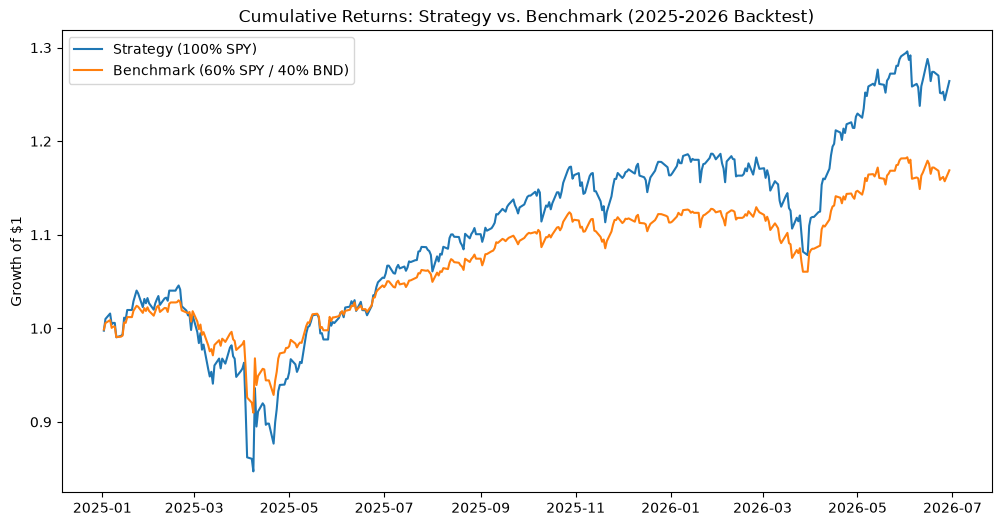

In [15]:
backtest = prices[prices.index >= "2025-01-01"].copy()
backtest_returns = backtest.pct_change().dropna()

strategy_weights = pd.Series(cleaned_max_sharpe)  # {'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}
benchmark_weights = pd.Series({"TSLA": 0.0, "BND": 0.40, "SPY": 0.60})

strategy_daily_returns = (backtest_returns * strategy_weights).sum(axis=1)
benchmark_daily_returns = (backtest_returns * benchmark_weights).sum(axis=1)

strategy_cumulative = (1 + strategy_daily_returns).cumprod()
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strategy_cumulative.index, strategy_cumulative, label="Strategy (100% SPY)")
ax.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark (60% SPY / 40% BND)")
ax.set_title("Cumulative Returns: Strategy vs. Benchmark (2025-2026 Backtest)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.show()

In [16]:
def backtest_metrics(daily_returns, label):
    total_return = (1 + daily_returns).prod() - 1
    n_years = len(daily_returns) / 252
    annualized_return = (1 + total_return) ** (1 / n_years) - 1
    annualized_vol = daily_returns.std() * np.sqrt(252)
    sharpe = annualized_return / annualized_vol

    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    print(f"--- {label} ---")
    print(f"Total Return: {total_return*100:.2f}%")
    print(f"Annualized Return: {annualized_return*100:.2f}%")
    print(f"Annualized Volatility: {annualized_vol*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.4f}")
    print(f"Max Drawdown: {max_drawdown*100:.2f}%\n")

    return {
        "Total Return": total_return, "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol, "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

strategy_metrics = backtest_metrics(strategy_daily_returns, "Strategy (100% SPY)")
benchmark_metrics = backtest_metrics(benchmark_daily_returns, "Benchmark (60/40 SPY/BND)")

comparison_df = pd.DataFrame({"Strategy": strategy_metrics, "Benchmark": benchmark_metrics}).T
comparison_df

--- Strategy (100% SPY) ---
Total Return: 26.43%
Annualized Return: 16.45%
Annualized Volatility: 17.55%
Sharpe Ratio: 0.9378
Max Drawdown: -19.00%

--- Benchmark (60/40 SPY/BND) ---
Total Return: 16.89%
Annualized Return: 10.67%
Annualized Volatility: 10.98%
Sharpe Ratio: 0.9717
Max Drawdown: -11.67%



,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy,0.264332,0.164548,0.175463,0.937791,-0.189989
Benchmark,0.168899,0.106675,0.109784,0.971681,-0.116707


## Task 5: Backtest Conclusion

**Did the strategy outperform the benchmark?** In absolute terms, yes: the 100% SPY 
strategy returned 26.43% over the backtest period versus the benchmark's 16.89% — a 
substantial margin. However, this outperformance came from taking on more risk, not 
from superior risk-adjusted skill: the strategy's Sharpe Ratio (0.938) was slightly 
*below* the benchmark's (0.972), and its maximum drawdown (-19.00%) was significantly 
worse than the benchmark's (-11.67%). An investor who needed to stay invested through 
the April 2025 drawdown would have experienced a notably larger paper loss with the 
strategy than with the benchmark.

**What this suggests about the model-driven approach:** the "success" of this backtest 
is almost entirely a story about SPY's strong standalone performance over this specific 
12-month window, rather than a demonstration that the forecasting-driven optimization 
process added value. Because the LSTM forecast pushed TSLA's expected return negative, 
the "optimization" step simply concentrated the portfolio into the single best-performing 
historical asset (SPY) and abandoned diversification entirely — which happened to work 
well in this period but is a fragile, backward-looking outcome, not a repeatable edge. 
A genuinely skill-based result would show the optimizer beating the benchmark on a 
risk-adjusted basis, which it did not.

**Limitations of this backtest:**
- Single 18-month window, no out-of-sample robustness check across other periods
- No transaction costs, taxes, or slippage modeled
- Static "hold" simulation — no rebalancing back to target weights over the period
- The 100% SPY allocation is a direct artifact of a single point-forecast for TSLA; a 
  different forecast horizon or method could plausibly have produced a very different 
  (and more diversified) recommended portfolio, which would backtest differently
- Survivorship/regime risk: SPY's strong performance in 2025-2026 is not guaranteed to 
  persist, and a fully undiversified portfolio carries more path-dependent risk than 
  the benchmark going forward, even if this backtest window rewarded it